In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

patients = pd.read_csv(r"C:\Users\G.Tanuja\Downloads\patients_stays.csv")

In [14]:
patients.head()

,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76


In [15]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-null   object
 4   departure_date  1000 non-null   object
 5   service         1000 non-null   object
 6   satisfaction    1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [16]:
patients.isnull().sum()

patient_id        0
name              0
age               0
arrival_date      0
departure_date    0
service           0
satisfaction      0
dtype: int64

In [17]:
patients = patients.copy()

# standardize columns
patients.columns = patients.columns.str.lower().str.strip().str.replace(" ", "_")

# drop name
patients = patients.drop(columns=["name"], errors="ignore")

# clean service
patients["service"] = patients["service"].str.lower().str.strip()

# convert dates
patients["arrival_date"] = pd.to_datetime(patients["arrival_date"], errors="coerce")
patients["departure_date"] = pd.to_datetime(patients["departure_date"], errors="coerce")

# create length of stay
patients["length_of_stay"] = (
    patients["departure_date"] - patients["arrival_date"]
).dt.days

# remove invalid rows
patients = patients[patients["length_of_stay"] >= 0]

# handle missing
patients = patients.dropna(subset=["service", "arrival_date", "departure_date"])

In [33]:
# Calculate length of stay
patients['stay_days'] = (
    patients['departure_date'] - patients['arrival_date']
).dt.days


print("Patients Stays:", patients.shape)

Patients Stays: (1000, 8)


In [18]:
patients.tail()

,patient_id,age,arrival_date,departure_date,service,satisfaction,length_of_stay
995,PAT-a01bf534,26,2025-12-02,2025-12-04,emergency,91,2
996,PAT-87fa07bd,89,2025-11-18,2025-11-30,emergency,99,12
997,PAT-8f07e894,72,2025-12-12,2025-12-21,icu,69,9
998,PAT-4ae301e1,47,2025-02-08,2025-02-20,icu,61,12
999,PAT-e2ef9c5f,64,2025-05-04,2025-05-08,general_medicine,83,4


In [8]:
from pathlib import Path

Path("cleaned_data").mkdir(parents=True, exist_ok=True)

In [19]:
patients.to_csv("cleaned_data/patient_stays_clean.csv", index=False)

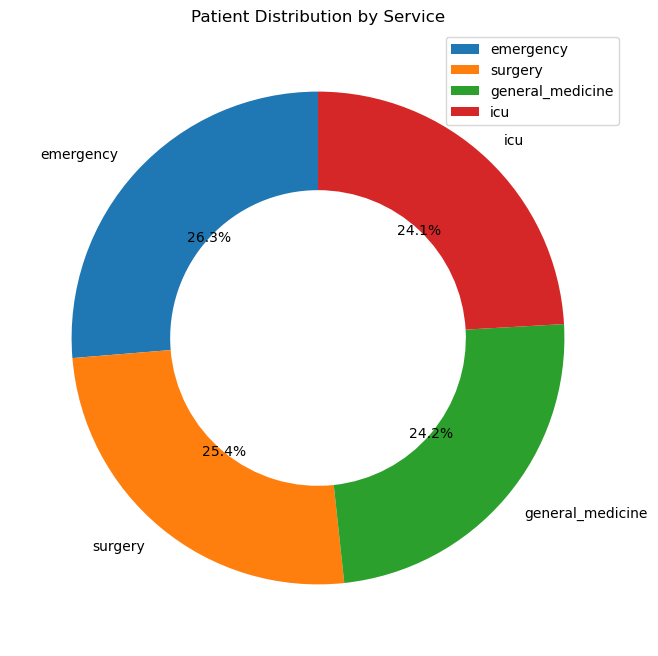

In [26]:
#Patients by Service
service_counts = patients['service'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    service_counts,
    labels=service_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Patient Distribution by Service')
plt.legend()
plt.show()

### Observations
* Patient volume is fairly evenly distributed across services.
* Surgery and Emergency have slightly higher patient volumes.
* No single service dominates the dataset.

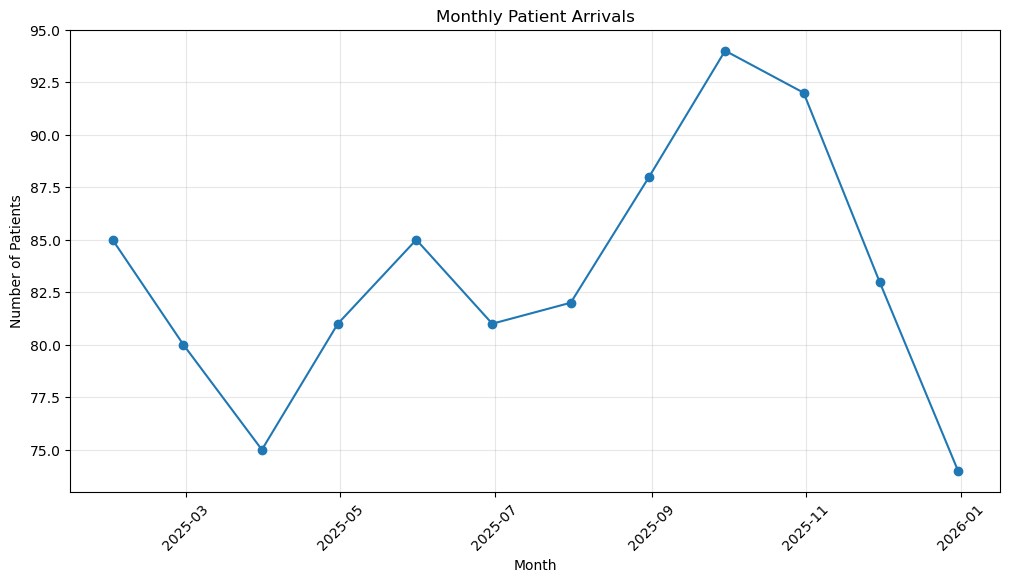

In [36]:
# Monthly Patient Arrivals
monthly_patients = (
    patients
    .set_index('arrival_date')
    .resample('ME')
    .size()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_patients.index,
    monthly_patients.values,
    marker='o'
)

plt.title('Monthly Patient Arrivals')
plt.xlabel('Month')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observations
* high-volume months
* low-volume months
* seasonal patterns
* unusual spikes or drops
* Monthly admission trends can help hospitals anticipate staffing and resource requirements.

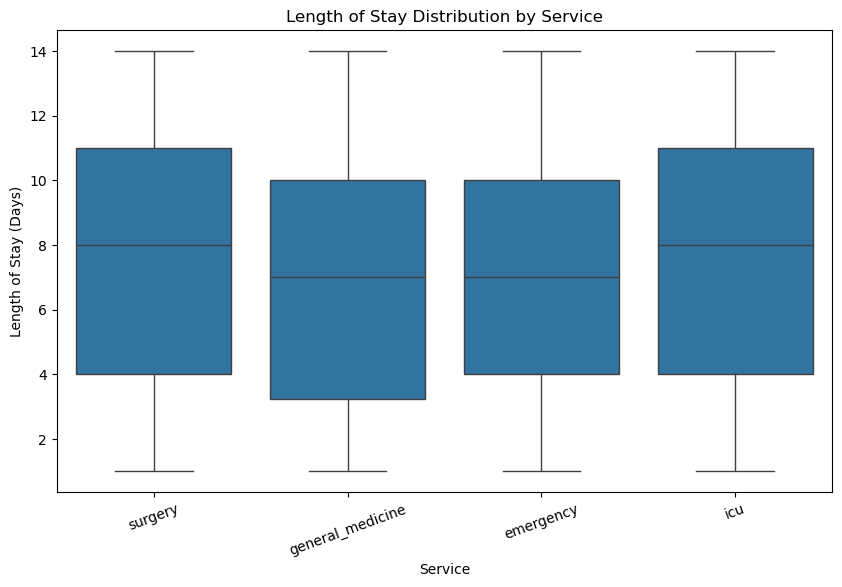

In [35]:
# Length of Stay by Service
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=patients,
    x='service',
    y='stay_days'
)

plt.title('Length of Stay Distribution by Service')
plt.xlabel('Service')
plt.ylabel('Length of Stay (Days)')

plt.xticks(rotation=20)

plt.show()

### Observations
* median stay
* spread
* unusually long stays
* differences between services

### Business Insight:
* Services with wider distributions may require closer monitoring of prolonged hospital stays.

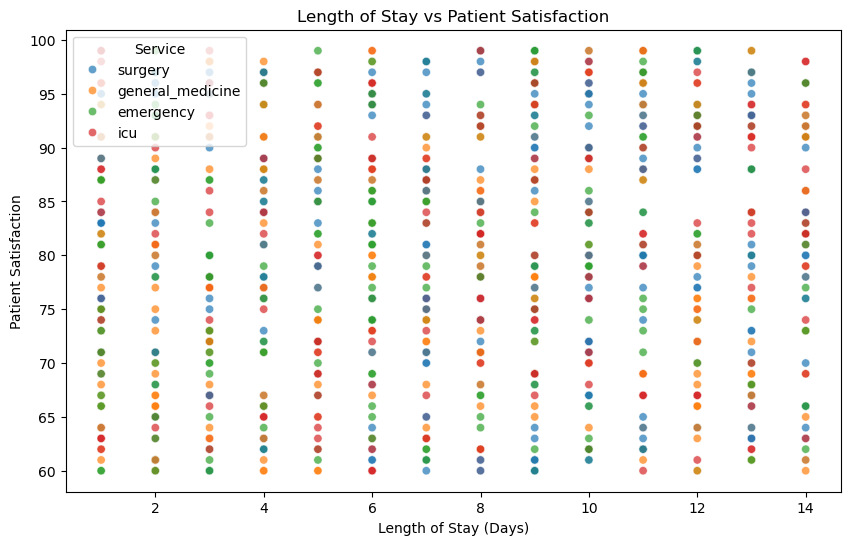

In [37]:
# Stay Duration vs Satisfaction
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=patients,
    x='stay_days',
    y='satisfaction',
    hue='service',
    alpha=0.7
)

plt.title('Length of Stay vs Patient Satisfaction')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Patient Satisfaction')

plt.legend(title='Service')

plt.show() 

### Observation
* The scatter plot is used to investigate whether length of stay is associated with patient satisfaction. The relationship should be confirmed using correlation analysis rather than visual inspection alone.

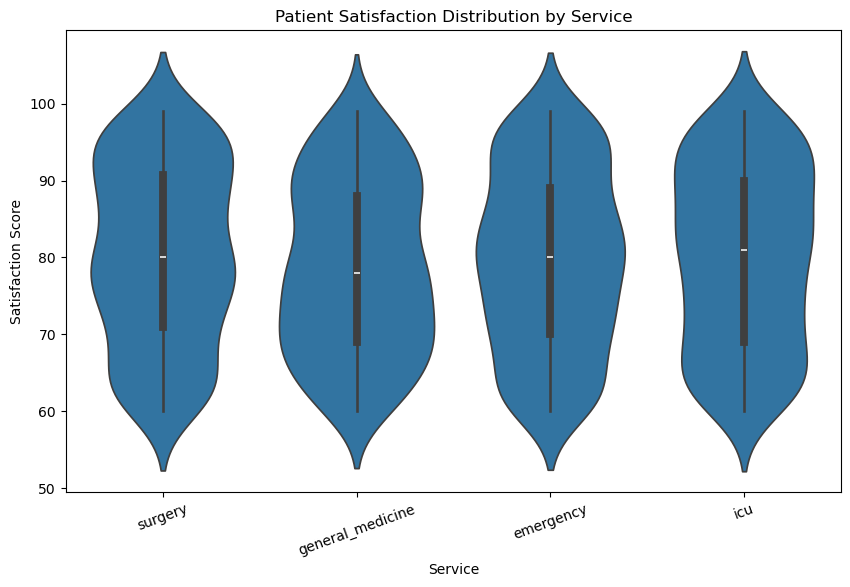

In [38]:
# Satisfaction by Service
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=patients,
    x='service',
    y='satisfaction'
)

plt.title('Patient Satisfaction Distribution by Service')
plt.xlabel('Service')
plt.ylabel('Satisfaction Score')

plt.xticks(rotation=20)

plt.show()